In [3]:
# --- Standard Python Utilities ---
import os
import glob
import random
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# --- Visualization & Image Processing ---
import matplotlib.pyplot as plt
from PIL import Image
import nibabel as nib
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize

# --- Scikit-Learn Utilities ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight

# --- TensorFlow & Keras Core ---
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import metrics
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# --- Keras Callbacks ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

# --- Keras Layers (Flattened API) ---
from tensorflow.keras.layers import (
    Input, 
    BatchNormalization, 
    Activation, 
    Dense, 
    Dropout, 
    Maximum, 
    PReLU,
    Lambda, 
    RepeatVector, 
    Reshape,
    Conv2D, 
    Conv2DTranspose, 
    Conv3D, 
    Conv3DTranspose,
    MaxPooling2D, 
    GlobalMaxPool2D, 
    MaxPooling3D,
    concatenate, 
    Add  # Note: Capitalized 'Add' is the correct functional layer for your V-Net residual connections
)

# Inline plotting for Jupyter/Kaggle notebook environments
%matplotlib inline

print("TensorFlow Version:", tf.__version__)
print("All modules imported successfully without errors!")

TensorFlow Version: 2.19.0
All modules imported successfully without errors!


In [ ]:
!pip install "numpy<2"

In [4]:
train_img_dir = "/kaggle/input/brats701515/input_data_128/train/images/"
train_mask_dir = "/kaggle/input/brats701515/input_data_128/train/masks/"

train_img_list = sorted(os.listdir(train_img_dir))
train_mask_list =  sorted(os.listdir(train_mask_dir))


In [5]:
batch_size = 2
# print(train_img_list,train_mask_list)

In [6]:
def load_img(img_dir , img_list):
    
    images = []
    for i,image_name in enumerate(img_list):
        
        if(image_name.split('.')[1]=='npy'):
            # if the file is numpy array
            
            image = np.load(img_dir + image_name)
            images.append(image)
        
    images = np.array(images)
        
    return (images)

In [7]:
def imageLoader(img_dir , img_list , mask_dir , mask_list , batch_size):
    
    L = len(img_list)
    
    while True:
        
        batch_start = 0
        batch_end = batch_size
        
        while batch_start < L:
            
            limit = min(batch_end , L)
            
            X = load_img(img_dir , img_list[batch_start:limit]) # load image
            Y = load_img(mask_dir , mask_list[batch_start:limit]) # load mask
            
            yield(X,Y) # yeilds images - a tuple with 2 numpy arrays with batch_size samples
            
            batch_start += batch_size
            batch_end += batch_size

In [8]:
train_img_datagen = imageLoader(train_img_dir, train_img_list,  train_mask_dir, train_mask_list, batch_size)

In [9]:
img, msk = train_img_datagen.__next__()

In [ ]:
img.shape

In [ ]:
msk.shape

In [10]:
img_num = random.randint(0,img.shape[0]-1)
test_img=img[img_num]
test_mask=msk[img_num]
test_mask=np.argmax(test_mask, axis=3)

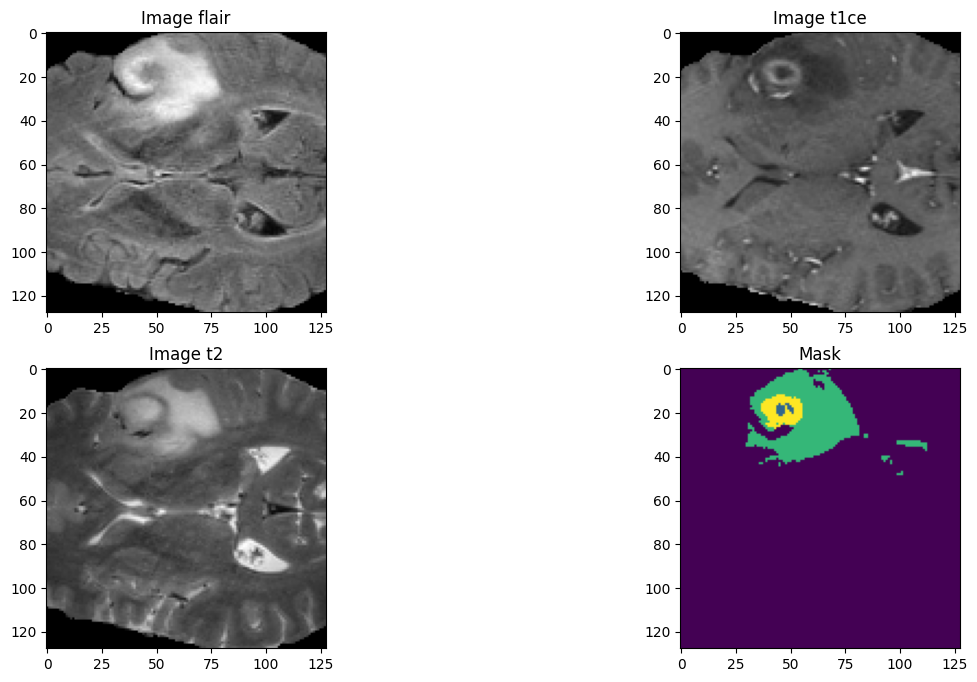

In [11]:
n_slice=random.randint(0, test_mask.shape[2])
n_slice=55
plt.figure(figsize=(15, 8))


plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv3D, Conv3DTranspose, concatenate, Add, 
    BatchNormalization, Activation, Dropout, Multiply
)

def attention_gate(inp_1, inp_2, channels):
    # Encoder pathway
    enc = Conv3D(channels, (3, 3, 3), activation='relu', padding='same')(inp_1)
    # Decoder pathway
    dec = Conv3D(channels, (3, 3, 3), activation='relu', padding='same')(inp_2)

    # Attention mechanism
    attn = Add()([enc, dec])
    attn = Conv3D(1, (1, 1, 1), activation='sigmoid')(attn)

    # Multiply attention weights with the input from the decoder pathway
    out = Multiply()([inp_2, attn])
    return out


def conv_block(input_mat, num_filters, kernel_size, batch_norm):
    X = Conv3D(num_filters, kernel_size=(kernel_size, kernel_size, kernel_size), strides=(1, 1, 1), padding='same')(input_mat)
    if batch_norm:
        X = BatchNormalization()(X)
    X = Activation('relu')(X)

    X = Conv3D(num_filters, kernel_size=(kernel_size, kernel_size, kernel_size), strides=(1, 1, 1), padding='same')(X)
    if batch_norm:
        X = BatchNormalization()(X)
    X = Activation('relu')(X)
      
    X = Add()([input_mat, X])
    return X


def Vnet_3d(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, n_filters=16, dropout=0.2, batch_norm=True):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))
    input_img = inputs

    c1 = Conv3D(n_filters, kernel_size=(5, 5, 5), strides=(1, 1, 1), padding='same')(input_img)
    c2 = Conv3D(n_filters*2, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(c1)
    
    c3 = conv_block(c2, n_filters*2, 5, True)
    
    p3 = Conv3D(n_filters*4, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(c3)
    p3 = Dropout(dropout)(p3)
    
    c4 = conv_block(p3, n_filters*4, 5, True)
    p4 = Conv3D(n_filters*8, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(c4)
    p4 = Dropout(dropout)(p4)
      
    c5 = conv_block(p4, n_filters*8, 5, True)
    p6 = Conv3D(n_filters*16, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(c5)
    p6 = Dropout(dropout)(p6)

    p7 = conv_block(p6, n_filters*16, 5, True)
      
    u6 = Conv3DTranspose(n_filters*8, (2, 2, 2), strides=(2, 2, 2), padding='same')(p7)
    gate1 = attention_gate(c5, u6, n_filters*8)
    u6 = concatenate([u6, gate1])
    c7 = conv_block(u6, n_filters*16, 5, True)
    c7 = Dropout(dropout)(c7)
    u7 = Conv3DTranspose(n_filters*4, (2, 2, 2), strides=(2, 2, 2), padding='same')(c7)

    print("c4 shape:", c4.shape)
    print("u7 shape:", u7.shape)
    
    gate2 = attention_gate(c4, u7, n_filters*4)  
    print("gate2 shape:", gate2.shape)
    
    u8 = concatenate([u7, gate2])
    c8 = conv_block(u8, n_filters*8, 5, True)
    c8 = Dropout(dropout)(c8)
    u9 = Conv3DTranspose(n_filters*2, (2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
      
    gate3 = attention_gate(c3, u9, n_filters*2)  
    u9 = concatenate([u9, gate3])
    c9 = conv_block(u9, n_filters*4, 5, True)
    c9 = Dropout(dropout)(c9)
    u10 = Conv3DTranspose(n_filters, (2, 2, 2), strides=(2, 2, 2), padding='same')(c9)
    
    gate4 = attention_gate(c1, u10, n_filters) 
    u10 = concatenate([u10, gate4])
    c10 = Conv3D(n_filters*2, kernel_size=(5, 5, 5), strides=(1, 1, 1), padding='same')(u10)
    c10 = Dropout(dropout)(c10)
    
    c10 = Add()([c10, u10])
    
    outputs = Conv3D(4, (1, 1, 1), activation='softmax')(c10)
    model = Model(inputs=[input_img], outputs=[outputs])
    
    model.summary()
    return model

# Initialize the model blueprint on your P100 GPU
model = Vnet_3d(128, 128, 128, 3)

c4 shape: (None, 32, 32, 32, 64)
u7 shape: (None, 32, 32, 32, 64)
gate2 shape: (None, 32, 32, 32, 64)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_16 (Conv3D)  │ (None, 128, 128,  │      6,016 │ input_layer_1[0]… │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_17 (Conv3D)  │ (None, 64, 64,    │      4,128 │ conv3d_16[0][0]   │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_18 (Conv3D)  │ (None, 64, 64,    │    128,032 │ conv3d_17[0][0]   │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_18[0][0]   │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_19 (Conv3D)  │ (None, 64, 64,    │    128,032 │ activation_8[0][… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_19[0][0]   │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 64, 64,    │          0 │ conv3d_17[0][0],  │
│                     │ 64, 32)           │            │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_20 (Conv3D)  │ (None, 32, 32,    │     16,448 │ add_5[0][0]       │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv3d_20[0][0]   │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_21 (Conv3D)  │ (None, 32, 32,    │    512,064 │ dropout_3[0][0]   │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_21[0][0]   │
│ (BatchNormalizatio… │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_22 (Conv3D)  │ (None, 32, 32,    │    512,064 │ activation_10[0]… │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_22[0][0] 

 Total params: 45,366,280 (173.06 MB)

 Trainable params: 45,362,568 (173.04 MB)

 Non-trainable params: 3,712 (14.50 KB)

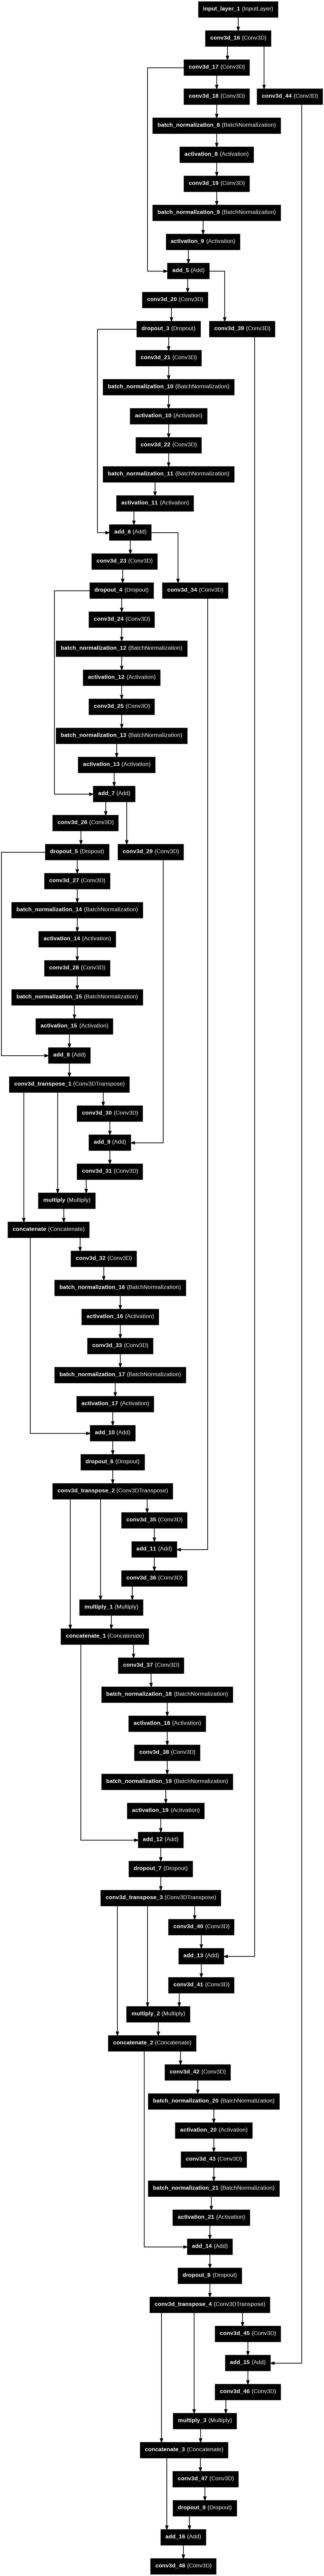

In [14]:
 #prining the model as image 

 from tensorflow.keras.utils import plot_model
 tf.keras.utils.plot_model(
     model,
     to_file="model.png",
     show_shapes=False,
     show_dtype=False,
     show_layer_names=True,
     rankdir="TB",
     expand_nested=False,
     dpi=96,
     layer_range=None,
     show_layer_activations=False,
)

In [15]:
print(model.input_shape)
print(model.output_shape)

(None, 128, 128, 128, 3)
(None, 128, 128, 128, 4)


In [16]:
img_list = sorted(os.listdir(train_img_dir))
print(len(img_list))
msk_list = sorted(os.listdir(train_mask_dir))
print(len(msk_list))


240
240


In [ ]:
 img_list

In [17]:
num_images = len(os.listdir(train_img_dir))

In [ ]:
img_num = random.randint(0,num_images-1)
test_img = np.load(train_img_dir+img_list[img_num])
test_mask = np.load(train_mask_dir+msk_list[img_num])
test_mask = np.argmax(test_mask, axis=3)

In [ ]:
# n_slice=random.randint(0, test_mask.shape[2])
n_slice = 55
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [18]:
val_img_dir = "/kaggle/input/brats701515/input_data_128/val/images/"
val_mask_dir = "/kaggle/input/brats701515/input_data_128/val/masks/"

train_img_list = sorted(os.listdir(train_img_dir))
train_mask_list = sorted(os.listdir(train_mask_dir))

val_img_list = sorted(os.listdir(val_img_dir))
val_mask_list = sorted(os.listdir(val_mask_dir))
print(len(os.listdir(val_img_dir)))
print(len(os.listdir(val_mask_dir)))

51
51


Image Agumentation for 3D Images

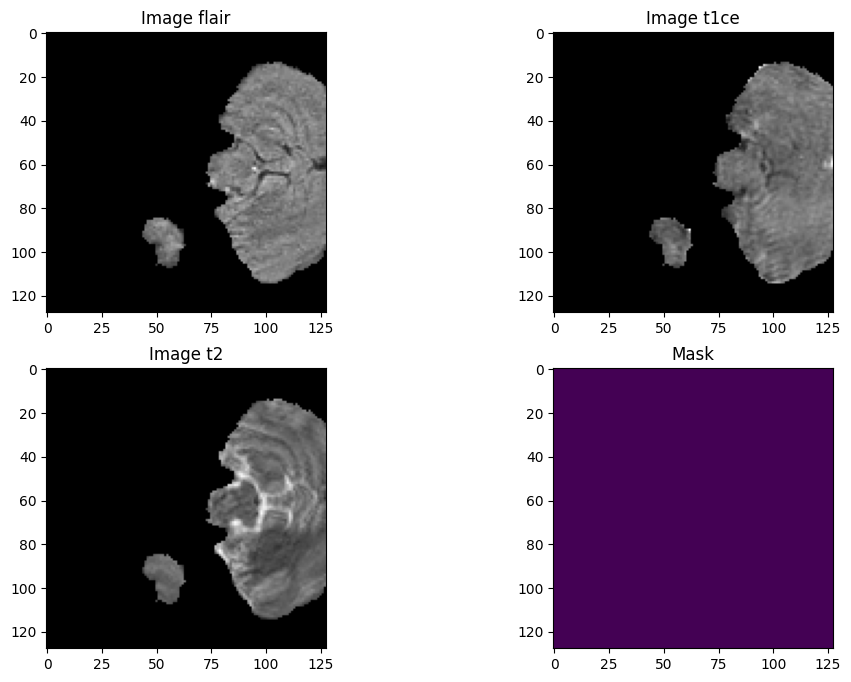

In [19]:
image='/kaggle/input/brats701515/input_data_128/train/images/image_0.npy'
mask ='/kaggle/input/brats701515/input_data_128/train/masks/mask_0.npy'

img_num = random.randint(0,num_images-1)
test_img = np.load(image)
test_mask = np.load(mask)
test_mask = np.argmax(test_mask, axis=3)



n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [20]:
batch_size=2
train_img_datagen = imageLoader(train_img_dir, train_img_list,  train_mask_dir, train_mask_list, batch_size)
val_img_datagen = imageLoader(val_img_dir, val_img_list, val_mask_dir, val_mask_list, batch_size)

In [ ]:
img, msk = train_img_datagen.__next__() 
img.shape
msk.shape

In [ ]:
steps_per_epoch = (len(train_img_list)//batch_size )+1
val_steps_per_epoch =( len(val_img_list)//batch_size )+1 

Defining the loss function and the optimizer function

In [21]:
# 1. Define Native Dice Coefficient & Loss (No external libraries needed)
def dice_coefficient(y_true, y_pred, smooth=1e-5):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def multi_class_dice_loss(y_true, y_pred, num_classes=4):
    """Computes the average Dice Loss across all 4 BraTS tumor classes."""
    loss = 0.0
    y_true = tf.cast(y_true, tf.float32)
    for i in range(num_classes):
        loss += (1.0 - dice_coefficient(y_true[..., i], y_pred[..., i]))
    return loss / num_classes

# 2. Compile Your Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=multi_class_dice_loss,
    metrics=[dice_coefficient]
)

print("Model compiled successfully! Ready for training.")

Model compiled successfully! Ready for training.


In [22]:
# Compute steps per epoch based on your batch size
steps_per_epoch = len(train_img_list) // batch_size
val_steps_per_epoch = len(val_img_list) // batch_size

# Start training!
history = model.fit(
    train_img_datagen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_img_datagen,
    validation_steps=val_steps_per_epoch,
    epochs=20  # Adjust based on your time constraints
)

Epoch 1/20


I0000 00:00:1778957351.205061     146 service.cc:152] XLA service 0x797ce9050650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778957351.205106     146 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778957353.991976     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-16 18:49:16.426320: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:49:16.676363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:49:21.326842: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=1,k3=0} for conv %cudnn-conv-bias-ac

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.7538 - loss: 0.6813

2026-05-16 18:55:46.396624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:55:46.639118: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:55:48.463420: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=4,k3=0} for conv %cudnn-conv-bias-activation.132 = (f32[2,32,128,128,128]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[2,32,128,128,128]{4,3,2,1,0} %bitcast.3551, f32[32,32,5,5,5]{4,3,2,1,0} %bitcast.3558, f32[32]{0} %bitcast.3560, f32[2,32,128,128,128]{4,3,2,1,0} %bitcast.3551), window={size=5x5x5 pad=2_2x2_2x2_2}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type

120/120 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - dice_coefficient: 0.7549 - loss: 0.6808 - val_dice_coefficient: 0.4474 - val_loss: 0.7776
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - dice_coefficient: 0.9561 - loss: 0.5414 - val_dice_coefficient: 0.6856 - val_loss: 0.7357
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.9600 - loss: 0.4983

2026-05-16 19:06:08.567335: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 19:06:08.793171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 19:06:11.622553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 19:06:11.835365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 19:06:12.441485: E external/local_xla/xla/stream_

120/120 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - dice_coefficient: 0.9600 - loss: 0.4983 - val_dice_coefficient: 0.8436 - val_loss: 0.5828
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - dice_coefficient: 0.9640 - loss: 0.4512 - val_dice_coefficient: 0.9542 - val_loss: 0.6395
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - dice_coefficient: 0.9663 - loss: 0.4240 - val_dice_coefficient: 0.9497 - val_loss: 0.4883
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - dice_coefficient: 0.9684 - loss: 0.4069 - val_dice_coefficient: 0.9564 - val_loss: 0.5035
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - dice_coefficient: 0.9702 - loss: 0.3888 - val_dice_coefficient: 0.9534 - val_loss: 0.5484
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - dice_coefficient: 0.9718 - loss: 0.3704 - val_dice_coefficient: 0.9583 - val_loss: 0.5532
Epoch 9/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - dice_coefficient: 0.9734 - loss: 0.3499 - val_dice_coefficient: 0.9576 - val_loss: 0.5

In [24]:
test_img_dir = "/kaggle/input/brats701515/input_data_128/test/images/"
test_mask_dir = "/kaggle/input/brats701515/input_data_128/test/masks/"

test_img_list = sorted(os.listdir(test_img_dir))
test_mask_list = sorted(os.listdir(test_mask_dir))

batch_size=2
test_img_datagen = imageLoader(test_img_dir, test_img_list,  test_mask_dir, test_mask_list, batch_size)
test_steps_per_epoch =(len(test_img_list)//batch_size )+1 

In [27]:
# 1. Capture the evaluation results as a single list
results = model.evaluate(
    test_img_datagen,      
    steps=test_steps_per_epoch,      
    verbose=1      
)

# 2. Dynamically print every metric name alongside its calculated value
print("\n=== Evaluation Results ===")
for metric_name, metric_value in zip(model.metrics_names, results):
    print(f"{metric_name}: {metric_value:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 980ms/step - dice_coefficient: 0.9681 - loss: 0.3547

=== Evaluation Results ===
loss: 0.3970
compile_metrics: 0.9676


In [28]:
def dice_score(o, t, eps=1e-8):
    num = 2*(o*t).sum() + eps
    den = o.sum() + t.sum() + eps
    return num/den

def softmax_output_dice(target,output):
    ret = []
    
    # whole   wt
    o = output > 0; t = target > 0 # ce
    ret += dice_score(o, t),
    
    # core   tc
    o = (output == 1) | (output == 3)
    t = (target == 1) | (target == 3)
    ret += dice_score(o, t),
    
    # active   et
    o = (output == 3);t = (target == 3)
    ret += dice_score(o, t),

    return ret


dice_scores_wt = []
dice_scores_tc = []
dice_scores_et = []
num_classes = 4

for batch in range(test_steps_per_epoch):
    
    test_img, test_mask = next(test_img_datagen)
    test_prediction = model.predict(test_img)
    
    test_mask_argmax=np.argmax(test_mask, axis=4)[0,:,:,:]
    test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]
    
    tensor = softmax_output_dice(test_mask_argmax, test_prediction_argmax)
    dice_batch = tensor[0]
    dice_scores_wt.append(dice_batch)
    dice_scores_tc.append(tensor[1])
    dice_scores_et.append(tensor[2])


print("Dice Scores for Vnet variation 2 trained for 120 epochs with dice loss")
average_dice_score_et = sum(dice_scores_et) / len(dice_scores_et)
print("Average Dice Score et:", average_dice_score_et)
average_dice_score_wt = sum(dice_scores_wt) / len(dice_scores_wt)
print("Average Dice Score wt:", average_dice_score_wt)
average_dice_score_tc = sum(dice_scores_tc) / len(dice_scores_tc)
print("Average Dice Score tc:", average_dice_score_tc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 924ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921

In [26]:
# Save only the weights
model.save_weights('resunet3d_weights.weights.h5')

print("Weights successfully saved as 'resunet3d_weights.weights.h5'")

Weights successfully saved as 'resunet3d_weights.weights.h5'


In [23]:
model.save('/kaggle/working/v_net_variation_2_dice_loss_120.hdf5')

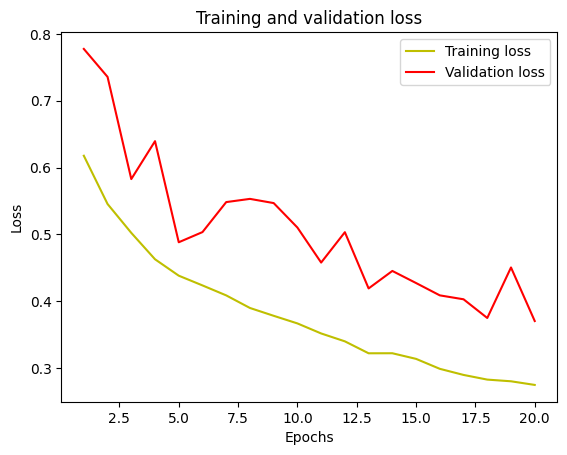

In [29]:
# metrics = ['accuracy', sm.metrics.IOUScore(threshold=0.5), mean_iou]
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [31]:
print(history.history.keys())

dict_keys(['dice_coefficient', 'loss', 'val_dice_coefficient', 'val_loss'])


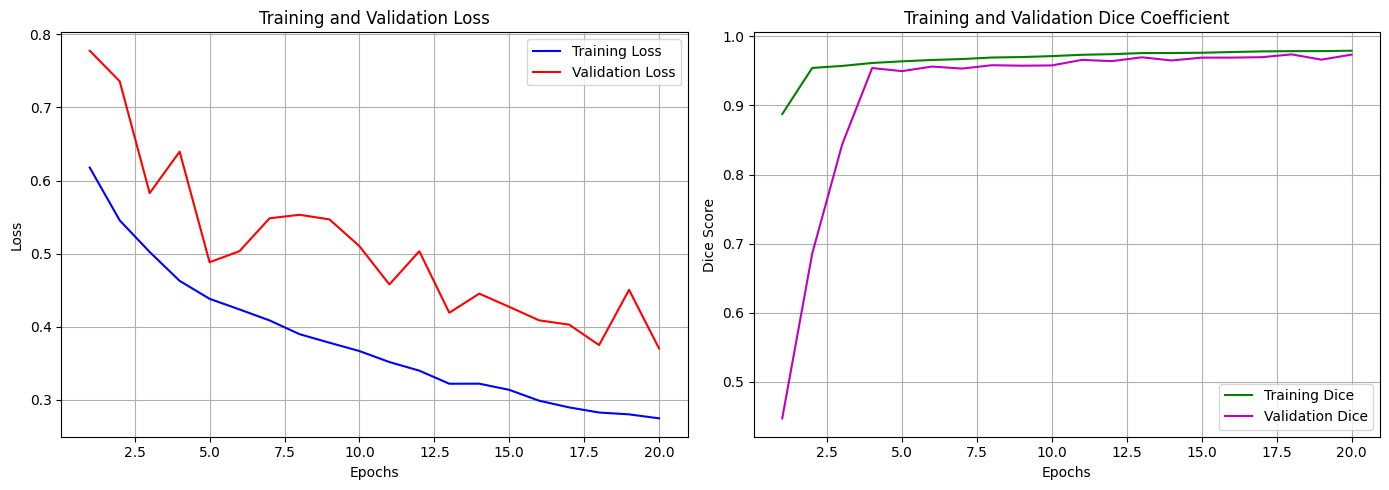

In [32]:
import matplotlib.pyplot as plt

# Extract the metrics that are actually present in your history
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Multi-Class Dice Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'b', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Dice Coefficient Overlap
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['dice_coefficient'], 'g', label='Training Dice')
plt.plot(epochs, history.history['val_dice_coefficient'], 'm', label='Validation Dice')
plt.title('Training and Validation Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
acc = history.history['iou_score']
val_acc = history.history['val_iou_score']

plt.plot(epochs, acc, 'y', label='Training iou_score')
plt.plot(epochs, val_acc, 'r', label='Validation iou_score')
plt.title('Training and validation iou_score')
plt.xlabel('Epochs')
plt.ylabel('iou_score')
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
from keras.losses import Loss
from keras.utils import get_custom_objects
get_custom_objects().update({"dice_loss": dice_loss})


get_custom_objects().update({"iou_score": sm.metrics.IOUScore(threshold=0.5)})

get_custom_objects().update({"mean_iou_score": tf.keras.metrics.MeanIoU(num_classes=4)})

In [35]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1. Load the model topology and weights while skipping the broken legacy compiler
my_model = load_model(
    '/kaggle/working/v_net_variation_2_dice_loss_120.hdf5', 
    compile=False
)

# 2. Manually re-compile it with your current loss and metrics
my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=multi_class_dice_loss, # Uses the native multi-class loss function we created earlier
    metrics=[dice_coefficient]
)

print("Model loaded and successfully re-compiled!")

Model loaded and successfully re-compiled!


In [36]:
img_num = 82

test_img = np.load("/kaggle/input/brats701515/input_data_128/test/images/image_"+str(img_num)+".npy")

test_mask = np.load("/kaggle/input/brats701515/input_data_128/test/masks/mask_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = my_model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]


print(test_prediction_argmax.shape)
print(test_mask_argmax.shape)
print(np.unique(test_mask_argmax))
print(np.unique(test_prediction_argmax))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]


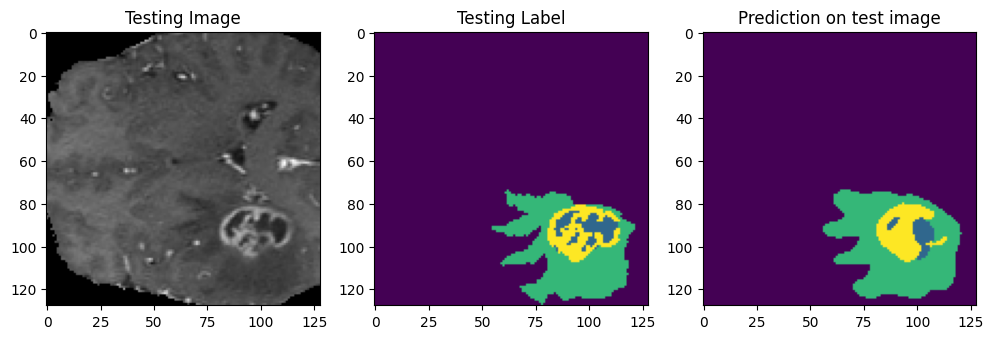

In [37]:
from matplotlib import pyplot as plt
import random

#n_slice=random.randint(0, test_prediction_argmax.shape[2])
n_slice = 55
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[:,:, n_slice])
plt.show()